In [4]:
import sys
import os

# Go one level up from notebooks/ to project root
sys.path.append(os.path.abspath(".."))

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from matcher import compute_similarity

In [16]:
data = [
    # --- POSITIVE MATCHES (1) ---
    ("Python ML SQL NLP", "Looking for ML engineer with Python and NLP", 1),
    ("Java Spring Boot", "Backend developer with Java", 1),
    ("Excel SQL Tableau", "Data analyst with SQL and dashboards", 1),
    ("Deep Learning TensorFlow", "Deep learning engineer", 1),
    ("React HTML CSS", "Frontend developer", 1),
    ("Python Data Analysis", "Data analyst with Python and SQL", 1),
    ("Machine Learning Python Scikit-learn", "ML engineer role", 1),
    ("SQL Data Visualization Power BI", "Business analyst with dashboards", 1),
    ("NLP Transformers BERT", "NLP engineer role", 1),
    ("Python Pandas NumPy", "Data analyst using Python libraries", 1),
    ("TensorFlow Deep Learning Python", "AI engineer deep learning", 1),
    ("Statistics SQL Python", "Data scientist role", 1),
    ("Power BI Excel SQL", "Reporting analyst role", 1),
    ("PyTorch Computer Vision", "Computer vision engineer", 1),

    # --- NEGATIVE MATCHES (0) ---
    ("Python ML", "Frontend developer React", 0),
    ("NLP Deep Learning", "Marketing specialist", 0),
    ("Java Spring Boot", "Data analyst with SQL", 0),
    ("Excel SQL", "Mobile app developer Kotlin", 0),
    ("React CSS", "Machine learning engineer", 0),
    ("Deep Learning", "Accountant role", 0),
    ("Python Pandas", "Graphic designer Photoshop", 0),
    ("SQL Tableau", "Civil engineer construction", 0),
    ("TensorFlow", "HR manager role", 0),
    ("Machine Learning", "Sales executive", 0),
    ("Python Data Analysis", "Mechanical engineer", 0),
    ("NLP Transformers", "Lawyer legal advisor", 0),
]

df = pd.DataFrame(data, columns=["Resume", "JD", "Label"])
df

,Resume,JD,Label
0,Python ML SQL NLP,Looking for ML engineer with Python and NLP,1
1,Java Spring Boot,Backend developer with Java,1
2,Excel SQL Tableau,Data analyst with SQL and dashboards,1
3,Deep Learning TensorFlow,Deep learning engineer,1
4,React HTML CSS,Frontend developer,1
5,Python Data Analysis,Data analyst with Python and SQL,1
6,Machine Learning Python Scikit-learn,ML engineer role,1
7,SQL Data Visualization Power BI,Business analyst with dashboards,1
8,NLP Transformers BERT,NLP engineer role,1
9,Python Pandas NumPy,Data analyst using Python libraries,1


In [20]:
df["score"] = df.apply(lambda x: compute_similarity(x["Resume"], x["JD"]), axis=1)
df

,Resume,JD,Label,score
0,Python ML SQL NLP,Looking for ML engineer with Python and NLP,1,0.650225
1,Java Spring Boot,Backend developer with Java,1,0.333286
2,Excel SQL Tableau,Data analyst with SQL and dashboards,1,0.496992
3,Deep Learning TensorFlow,Deep learning engineer,1,0.648131
4,React HTML CSS,Frontend developer,1,0.094569
5,Python Data Analysis,Data analyst with Python and SQL,1,0.632786
6,Machine Learning Python Scikit-learn,ML engineer role,1,0.207287
7,SQL Data Visualization Power BI,Business analyst with dashboards,1,0.338107
8,NLP Transformers BERT,NLP engineer role,1,0.442076
9,Python Pandas NumPy,Data analyst using Python libraries,1,0.378050


In [23]:
threshold = 0.6
df["pred"] = df["score"].apply(lambda x: 1 if x > threshold else 0)
df

,Resume,JD,Label,score,pred
0,Python ML SQL NLP,Looking for ML engineer with Python and NLP,1,0.650225,1
1,Java Spring Boot,Backend developer with Java,1,0.333286,0
2,Excel SQL Tableau,Data analyst with SQL and dashboards,1,0.496992,0
3,Deep Learning TensorFlow,Deep learning engineer,1,0.648131,1
4,React HTML CSS,Frontend developer,1,0.094569,0
5,Python Data Analysis,Data analyst with Python and SQL,1,0.632786,1
6,Machine Learning Python Scikit-learn,ML engineer role,1,0.207287,0
7,SQL Data Visualization Power BI,Business analyst with dashboards,1,0.338107,0
8,NLP Transformers BERT,NLP engineer role,1,0.442076,0
9,Python Pandas NumPy,Data analyst using Python libraries,1,0.378050,0


In [24]:
accuracy = (df["Label"] == df["pred"]).mean()
print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 57.69 %


In [25]:
cm = confusion_matrix(df["Label"], df["pred"])
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[12  0]
 [11  3]]


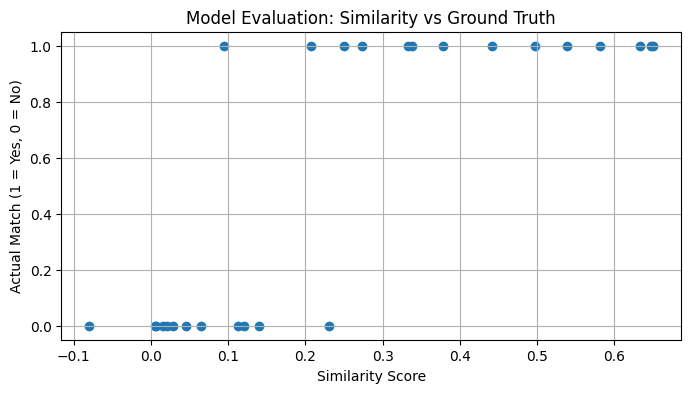

In [26]:
plt.figure(figsize=(8,4))
plt.scatter(df["score"], df["Label"])

plt.xlabel("Similarity Score")
plt.ylabel("Actual Match (1 = Yes, 0 = No)")
plt.title("Model Evaluation: Similarity vs Ground Truth")

plt.grid(True)
plt.show()